# UCI Adult Census Income Project

**Goal:** To predict whether an individual earns more than $50K per year using the UCI Adult Census dataset.

**Group members :**

Aishwarya Murthy

Sangeetha Radjavel

Shanmuga  perumal Balamurugan


**Sections:**

1. Data cleaning and preparation
2. Feature transformation and engineering
3. Unsupervised learning (K Means)
4. Visualization and exploration
5. Modeling and prediction

## Setup

Installing PySpark and then importing the necessary libraries.

In [19]:
!pip install pyspark -q


In [42]:
# Install requirements.txt 
!pip install -r requirements.txt

  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# PySpark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType

from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler,
    StandardScaler, PCA
)

# PySpark ML
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("All imports are completed")


All imports are completed


In [22]:
# Starting  up a local Spark session

spark =SparkSession.builder \
    .appName("UCI Adult Income Analysis") \
    .master("local[*]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print(f"Spark version:{spark.version}")


Spark version:4.1.1


## Step 1: Data cleaning and preparation


- Treating the `?` mark as missing values.
- Trim whitespace in categorical columns.
- Impute missing values in `workclass` and `occupation` using the most frequent category.
- Checking redundancy between `education` and `education-num` and keeping the most useful representation.

In [23]:
##Load the CSV

DATA_PATH = "adult.csv"

df =spark.read.csv(
    DATA_PATH,
    header=True,
    inferSchema=True
)

# Some column names in this dataset contain '.' or '-' which can break Spark column references.
# Renaming them to keep everything consistent.
df =df.toDF(*[c.strip().replace('-', '_').replace('.', '_') for c in df.columns])

print(f"Rows: {df.count():,} | Columns: {len(df.columns)}")
df.printSchema()


Rows: 32,561 | Columns: 15
root
 |-- age: integer (nullable = true)
 |-- workclass: string (nullable = true)
 |-- fnlwgt: integer (nullable = true)
 |-- education: string (nullable = true)
 |-- education_num: integer (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- relationship: string (nullable = true)
 |-- race: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- capital_gain: integer (nullable = true)
 |-- capital_loss: integer (nullable = true)
 |-- hours_per_week: integer (nullable = true)
 |-- native_country: string (nullable = true)
 |-- income: string (nullable = true)



In [24]:
#Strip leading whitespace from all the string columns

string_cols =[f.name for f in df.schema.fields if str(f.dataType) == 'StringType()']

for col in string_cols:
    df = df.withColumn(col, F.trim(F.col(col)))

print(f"Cleaned whitespace in columns: {string_cols}")


Cleaned whitespace in columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


In [25]:
#Replace '?' with None (real nulls) so Spark can handle them properly.
for col in string_cols:
    df = df.withColumn(col, F.when(F.col(col) == '?', None).otherwise(F.col(col)))

print("Missing values per column:")
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show()


Missing values per column:
+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+
|age|workclass|fnlwgt|education|education_num|marital_status|occupation|relationship|race|sex|capital_gain|capital_loss|hours_per_week|native_country|income|
+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+
|  0|     1836|     0|        0|            0|             0|      1843|           0|   0|  0|           0|           0|             0|           583|     0|
+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+



In [26]:
#Filling the  missing 'workclass' and 'occupation' with the most frequent value.

def get_mode(df, col_name):
    """Returns the most frequent value in a column."""
    return (
        df.groupBy(col_name)
        .count()
        .orderBy(F.desc('count'))
        .filter(F.col(col_name).isNotNull())
        .first()[0]
    )

workclass_mode = get_mode(df, 'workclass')
occupation_mode = get_mode(df, 'occupation')

print(f"Most common workclass: '{workclass_mode}'")
print(f"Most common occupation: '{occupation_mode}'")

df =df.fillna({'workclass': workclass_mode, 'occupation': occupation_mode})

# Verifing  nulls are gone
remaining =df.filter(F.col('workclass').isNull() | F.col('occupation').isNull()).count()
print(f"\nRemaining nulls in those two columns: {remaining}")


Most common workclass: 'Private'
Most common occupation: 'Prof-specialty'

Remaining nulls in those two columns: 0


In [27]:
#Checking if 'education' and 'education_num' are redundant
# If each education label maps to exactly one number,they keeping the same information

edu_check = df.groupBy('education', 'education_num').count().orderBy('education_num')
edu_check.show(20, truncate=False)

unique_labels = df.select('education').distinct().count()
unique_combos = df.select('education', 'education_num').distinct().count()

print(f"Unique education labels: {unique_labels}")
print(f"Unique (education, education_num) combos: {unique_combos}")

if unique_labels == unique_combos:
    print("Perfectone to one mapping :'education' and 'education_num' are REDUNDANT.")
    print("keep 'education_num' (it's numeric and easier for ML) and drop 'education'.")


+------------+-------------+-----+
|education   |education_num|count|
+------------+-------------+-----+
|Preschool   |1            |51   |
|1st-4th     |2            |168  |
|5th-6th     |3            |333  |
|7th-8th     |4            |646  |
|9th         |5            |514  |
|10th        |6            |933  |
|11th        |7            |1175 |
|12th        |8            |433  |
|HS-grad     |9            |10501|
|Some-college|10           |7291 |
|Assoc-voc   |11           |1382 |
|Assoc-acdm  |12           |1067 |
|Bachelors   |13           |5355 |
|Masters     |14           |1723 |
|Prof-school |15           |576  |
|Doctorate   |16           |413  |
+------------+-------------+-----+

Unique education labels: 16
Unique (education, education_num) combos: 16
Perfectone to one mapping :'education' and 'education_num' are REDUNDANT.
keep 'education_num' (it's numeric and easier for ML) and drop 'education'.


In [28]:
#Dropping the text-based education column since education_num captures the same numerical information

df =df.drop('education')

print(f"Remaining columns:{df.columns}")


Remaining columns:['age', 'workclass', 'fnlwgt', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


In [29]:
df.show(5, truncate=False)


+---+---------+------+-------------+--------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
|age|workclass|fnlwgt|education_num|marital_status|occupation       |relationship |race |sex   |capital_gain|capital_loss|hours_per_week|native_country|income|
+---+---------+------+-------------+--------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
|90 |Private  |77053 |9            |Widowed       |Prof-specialty   |Not-in-family|White|Female|0           |4356        |40            |United-States |<=50K |
|82 |Private  |132870|9            |Widowed       |Exec-managerial  |Not-in-family|White|Female|0           |4356        |18            |United-States |<=50K |
|66 |Private  |186061|10           |Widowed       |Prof-specialty   |Unmarried    |Black|Female|0           |4356        |40            |United-States |<=50K |
|54 |Private  |140359|4            |Divo

## Step 2: Feature transformation and engineering

This section converts the target into a numeric label and adds a few compact features that help modeling.

Added features include:
- `income_label` as 0 for <=50K and 1 for >50K
- `age_group` bins
- `net_capital` as capital.gain minus capital.loss
- `country_region` to reduce sparsity from rare countries

In [30]:
#Converting income to binary: 0 = <=50K, 1 = >50K

df = df.withColumn(
    'income_binary',
    F.when(F.col('income') =='>50K', 1).otherwise(0).cast(IntegerType())
)

# Checking the class balance before modelling.
print("Class distribution:")
df.groupBy('income', 'income_binary').count() \
  .orderBy('income_binary')\
  .show()


Class distribution:
+------+-------------+-----+
|income|income_binary|count|
+------+-------------+-----+
| <=50K|            0|24720|
|  >50K|            1| 7841|
+------+-------------+-----+



In [31]:
#Creating age groups
#Splitting age into buckets helps the model handle non-linear relationships

df = df.withColumn('age_group',
    F.when(F.col('age') < 25,'Young (< 25)')
     .when(F.col('age') < 45,'Prime (25-44)')
     .when(F.col('age') < 60,'Senior (45-59)')
     .otherwise('Elder (60+)')
)

print("Age group distribution:")
df.groupBy('age_group').count().orderBy('count', ascending=False).show()


Age group distribution:
+--------------+-----+
|     age_group|count|
+--------------+-----+
| Prime (25-44)|16630|
|Senior (45-59)| 7717|
|  Young (< 25)| 5570|
|   Elder (60+)| 2644|
+--------------+-----+



In [32]:
#Net capital=capital_gain - capital_loss
# Instead of two separate noisy columns,one combined feature is cleaner

df = df.withColumn('net_capital', F.col('capital_gain') - F.col('capital_loss'))

print("Net capital summary:")
df.select('net_capital').describe().show()


Net capital summary:
+-------+-----------------+
|summary|      net_capital|
+-------+-----------------+
|  count|            32561|
|   mean|990.3450139737723|
| stddev|7408.986950831768|
|    min|            -4356|
|    max|            99999|
+-------+-----------------+



In [33]:
#Group native countries into regions.
#Although the dataset includes over 40 countries, many have very few records, so reducing or grouping them helps avoid sparsity.

north_america =['United-States', 'Canada', 'Mexico', 'Cuba', 'Puerto-Rico',
                 'Jamaica', 'Dominican-Republic', 'Guatemala', 'El-Salvador',
                 'Haiti', 'Nicaragua', 'Honduras', 'Trinadad&Tobago', 'Outlying-US(Guam-USVI-etc)']

south_america =['Columbia', 'Peru', 'Ecuador']

asia =['India', 'China', 'Japan', 'Philippines', 'Vietnam', 'Taiwan',
        'Iran', 'Thailand', 'Hong', 'Cambodia', 'Laos']

europe =['Germany', 'England', 'Italy', 'Poland', 'Portugal', 'France',
          'Yugoslavia', 'Greece', 'Ireland', 'Hungary', 'Scotland', 'Holand-Netherlands']

df = df.withColumn('country_region',
    F.when(F.col('native_country').isin(north_america), 'North America')
     .when(F.col('native_country').isin(south_america), 'South America')
     .when(F.col('native_country').isin(asia), 'Asia')
     .when(F.col('native_country').isin(europe), 'Europe')
     .otherwise('Other')
)

print("Country regions:")
df.groupBy('country_region').count().orderBy('count', ascending=False).show()


Country regions:
+--------------+-----+
|country_region|count|
+--------------+-----+
| North America|30588|
|          Asia|  671|
|         Other|  663|
|        Europe|  521|
| South America|  118|
+--------------+-----+



In [34]:
df.select('age','age_group', 'capital_gain','capital_loss', 'net_capital',
          'native_country','country_region','income','income_binary').show(10)


+---+--------------+------------+------------+-----------+--------------+--------------+------+-------------+
|age|     age_group|capital_gain|capital_loss|net_capital|native_country|country_region|income|income_binary|
+---+--------------+------------+------------+-----------+--------------+--------------+------+-------------+
| 90|   Elder (60+)|           0|        4356|      -4356| United-States| North America| <=50K|            0|
| 82|   Elder (60+)|           0|        4356|      -4356| United-States| North America| <=50K|            0|
| 66|   Elder (60+)|           0|        4356|      -4356| United-States| North America| <=50K|            0|
| 54|Senior (45-59)|           0|        3900|      -3900| United-States| North America| <=50K|            0|
| 41| Prime (25-44)|           0|        3900|      -3900| United-States| North America| <=50K|            0|
| 34| Prime (25-44)|           0|        3770|      -3770| United-States| North America| <=50K|            0|
| 38| Prim

## Step 3: Unsupervised learning (Pattern discovery)

Applying K Means algorithm.

K Means is applied on selected continuous variables to find natural groupings, then the clusters are profiled to see how they relate to income.

In [35]:
#Prepare features for clustering

continuous_cols =['age','hours_per_week','education_num','net_capital']

assembler =VectorAssembler(inputCols=continuous_cols,outputCol='features_raw')

# Standardizing so that no single feature dominates due to scale differences.
scaler =StandardScaler(inputCol='features_raw', outputCol='features_scaled',
                        withStd=True, withMean=True)

# Building and applying the pipeline
pipeline_prep =Pipeline(stages=[assembler, scaler])
df_kmeans_ready =pipeline_prep.fit(df).transform(df)

print("Features assembled and scaled for K-Means")


Features assembled and scaled for K-Means


In [36]:
#Training K-Means with 4 clusters based on expected natural groupings
#such as young low earners, mid career individuals, high earners, and retired or part time workers

kmeans =KMeans(featuresCol='features_scaled', k=4, seed=42)
kmeans_model= kmeans.fit(df_kmeans_ready)

df_clustered = kmeans_model.transform(df_kmeans_ready)

print(f"K Means Silhouette:{kmeans_model.summary.trainingCost:.2f}")


K Means Silhouette:69007.75


In [37]:
# Analyzing each cluster what does the 'average person' in each group look like?

cluster_profile = df_clustered.groupBy('prediction').agg(
    F.count('*').alias('count'),
    F.round(F.avg('age'), 1).alias('avg_age'),
    F.round(F.avg('hours_per_week'), 1).alias('avg_hours'),
    F.round(F.avg('education_num'), 1).alias('avg_edu_level'),
    F.round(F.avg('net_capital'), 0).alias('avg_net_capital'),
    F.round(F.avg('income_binary') * 100, 1).alias('pct_high_income')
).orderBy('prediction')

cluster_profile.show()


+----------+-----+-------+---------+-------------+---------------+---------------+
|prediction|count|avg_age|avg_hours|avg_edu_level|avg_net_capital|pct_high_income|
+----------+-----+-------+---------+-------------+---------------+---------------+
|         0|18602|   36.6|     35.5|          8.6|          204.0|           11.4|
|         1| 4909|   40.1|     58.6|         10.0|          639.0|           34.9|
|         2|  159|   46.4|     49.8|         12.9|        99999.0|          100.0|
|         3| 8891|   41.8|     40.6|         13.1|         1058.0|           43.4|
+----------+-----+-------+---------+-------------+---------------+---------------+



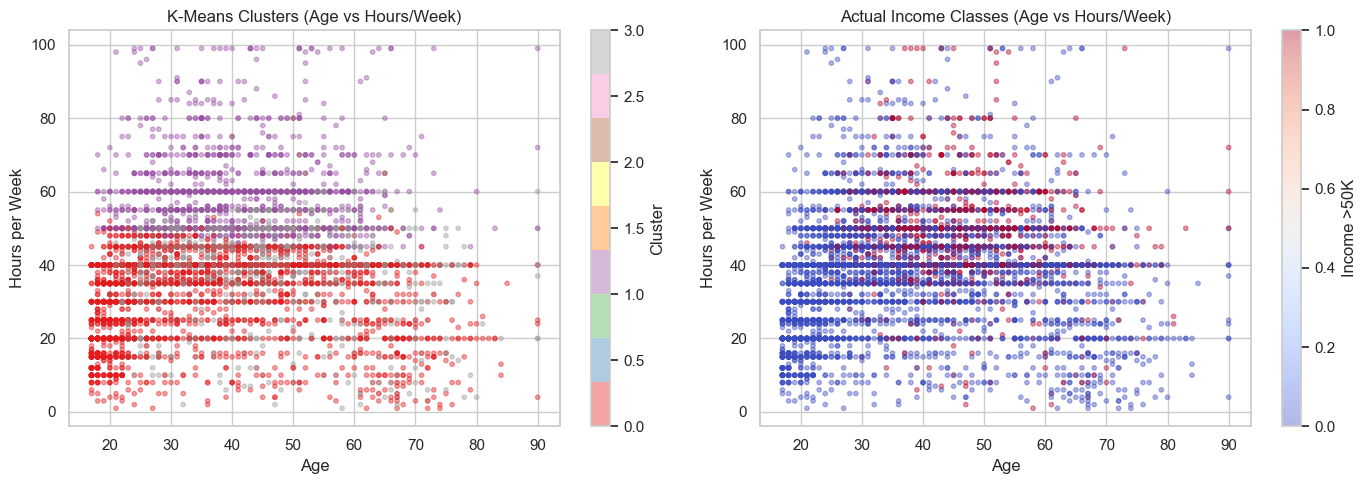

In [38]:
# Visualize the clusters:age vs hours-per-week, coloured by cluster
# Convert a sample to Pandas for plotting (Spark can't plot natively)

df_plot = df_clustered.select('age', 'hours_per_week', 'prediction', 'income_binary') \
                      .sample(fraction=0.3, seed=42) \
                      .toPandas()
df_plot.rename(columns={'hours_per_week':'hours_per_week'},inplace=True)

fig, axes=plt.subplots(1, 2, figsize=(14, 5))

scatter =axes[0].scatter(df_plot['age'],df_plot['hours_per_week'],
                          c=df_plot['prediction'],cmap='Set1',alpha=0.4, s=10)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Hours per Week')
axes[0].set_title('K-Means Clusters (Age vs Hours/Week)')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

scatter2 =axes[1].scatter(df_plot['age'],df_plot['hours_per_week'],
                           c=df_plot['income_binary'],cmap='coolwarm',alpha=0.4, s=10)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Hours per Week')
axes[1].set_title('Actual Income Classes (Age vs Hours/Week)')
plt.colorbar(scatter2, ax=axes[1],label='Income >50K')

plt.tight_layout()
plt.savefig('kmeans_clusters.png',dpi=150,bbox_inches='tight')
plt.show()


## Step 4: Visualizations Exploration (with ggplot2)


Three visuals are produced:

1. Education level vs proportion earning more than $50K

2. Distribution of a continuous variable by income class (age)

3. A custom view (occupation vs proportion earning more than $50K)

In [39]:
# Converting full dataset to Pandas for visualization

pdf = df.toPandas()

pdf.columns = [c.replace('.', '_') for c in pdf.columns]

print(f"DataFrame shape: {pdf.shape}")
pdf.head(3)


DataFrame shape: (32561, 18)


,age,workclass,fnlwgt,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,income_binary,age_group,net_capital,country_region
0,90,Private,77053,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K,0,Elder (60+),-4356,North America
1,82,Private,132870,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,0,Elder (60+),-4356,North America
2,66,Private,186061,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K,0,Elder (60+),-4356,North America


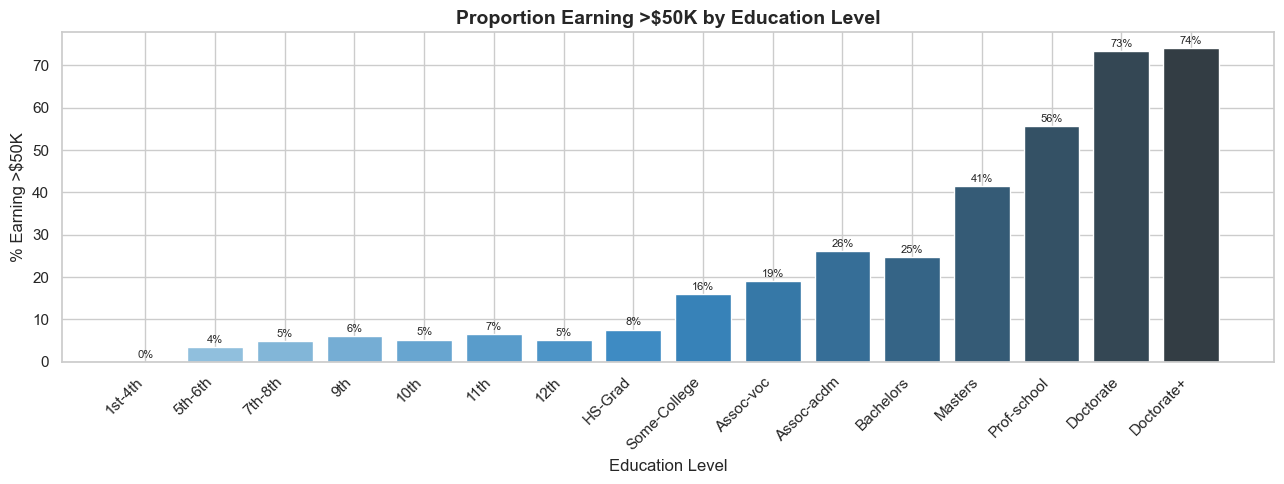

Higher education clearly correlates with higher income,
but the jump from Bachelors to Prof-school/Doctorate is a bit dramatic.


In [40]:
# Visualization 1:Education level vs % earning >50K
# Checking whether higher education levels are linked to a higher share of >50K income.

edu_income = pdf.groupby('education_num')['income_binary'].agg(['mean', 'count']).reset_index()
edu_income.columns = ['education_num', 'pct_high_income', 'count']
edu_income['pct_high_income'] = edu_income['pct_high_income'] * 100

# Map education numbers to labels for readability
edu_labels = {
    1: '1st-4th', 2: '5th-6th', 3:'7th-8th', 4: '9th',
    5: '10th', 6:'11th',7:'12th', 8: 'HS-Grad',
    9: 'Some-College', 10:'Assoc-voc', 11:'Assoc-acdm',
    12:'Bachelors', 13:'Masters', 14:'Prof-school', 15:'Doctorate', 16: 'Doctorate+'
}
edu_income['edu_label'] = edu_income['education_num'].map(edu_labels)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(edu_income['edu_label'], edu_income['pct_high_income'],
              color=sns.color_palette('Blues_d', len(edu_income)))

# Adding percentage labels on top of each bar
for bar, pct in zip(bars, edu_income['pct_high_income']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.0f}%', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Education Level', fontsize=12)
ax.set_ylabel('% Earning >$50K', fontsize=12)
ax.set_title('Proportion Earning >$50K by Education Level', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('viz1_education_income.png', dpi=150, bbox_inches='tight')
plt.show()

print("Higher education clearly correlates with higher income,")
print("but the jump from Bachelors to Prof-school/Doctorate is a bit dramatic.")


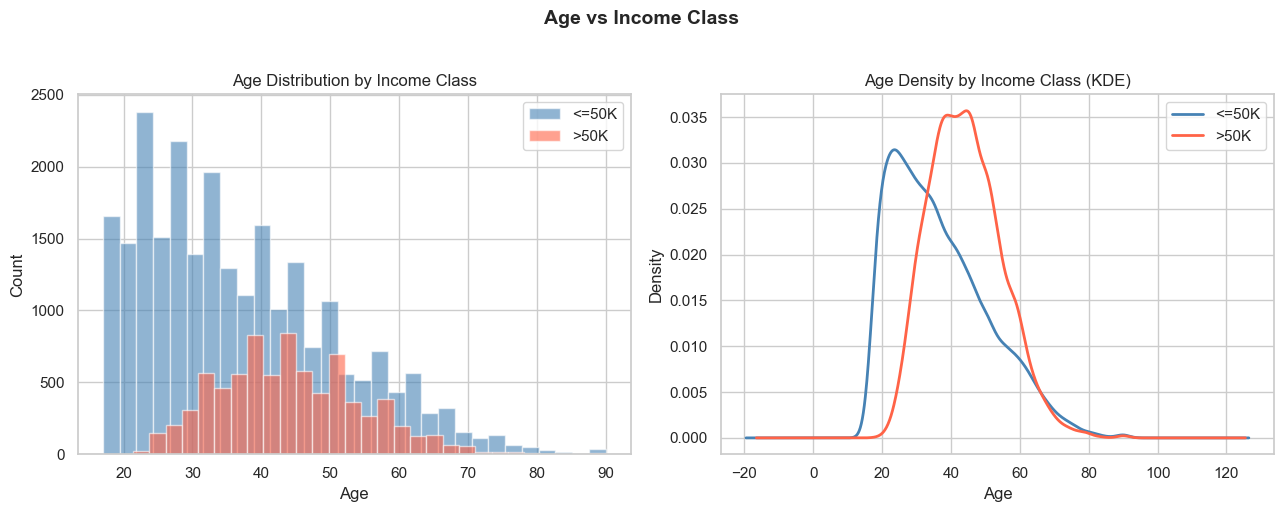

Mean age (<=50K):36.8
Mean age (>50K):44.2


In [43]:
# Visualization 2:Age distribution by income class
# Compare the age distribution for different income groups.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(pdf[pdf['income_binary'] == 0]['age'], bins=30, alpha=0.6,
             label='<=50K', color='steelblue', edgecolor='white')
axes[0].hist(pdf[pdf['income_binary'] == 1]['age'], bins=30, alpha=0.6,
             label='>50K', color='tomato', edgecolor='white')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Income Class')
axes[0].legend()

for income_class, color, label in [(0, 'steelblue', '<=50K'), (1, 'tomato', '>50K')]:
    subset = pdf[pdf['income_binary'] == income_class]['age']
    subset.plot.kde(ax=axes[1], color=color, label=label, linewidth=2)

axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].set_title('Age Density by Income Class (KDE)')
axes[1].legend()

plt.suptitle('Age vs Income Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz2_age_income.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean age (<=50K):{pdf[pdf['income_binary']==0]['age'].mean():.1f}")
print(f"Mean age (>50K):{pdf[pdf['income_binary']==1]['age'].mean():.1f}")


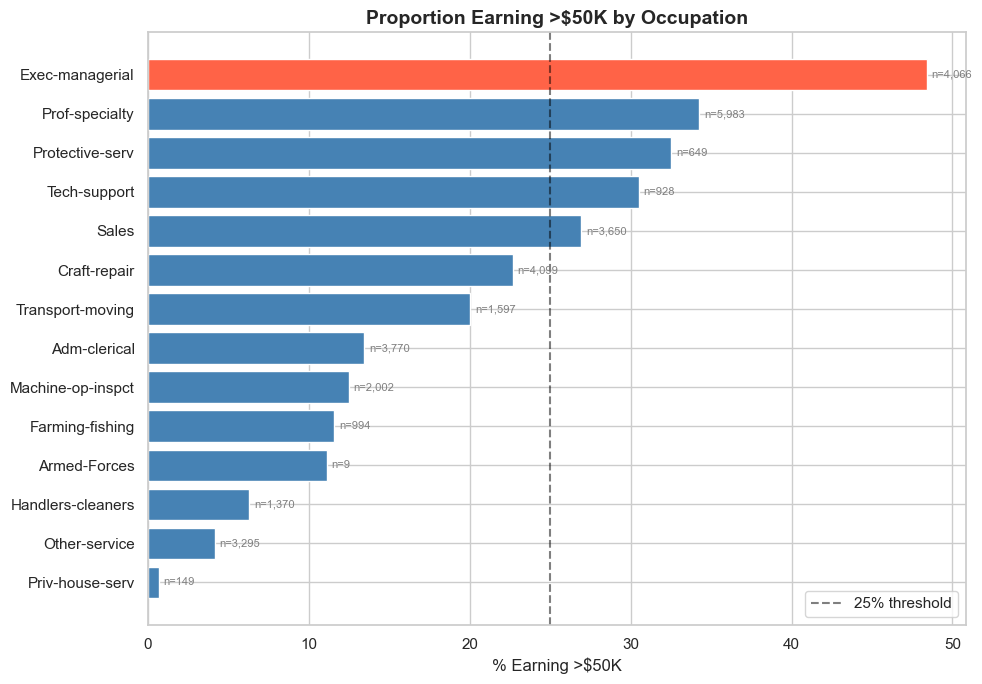

In [44]:
# Visualization 3:  Custom: % earning >50K by occupation (sorted)
# Which jobs actually pay?

occ_income = pdf.groupby('occupation')['income_binary'].agg(['mean', 'count']).reset_index()
occ_income.columns = ['occupation', 'pct_high_income', 'count']
occ_income['pct_high_income'] = occ_income['pct_high_income'] * 100
occ_income = occ_income.sort_values('pct_high_income', ascending=True)

colors = ['tomato' if x > 35 else 'steelblue' for x in occ_income['pct_high_income']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(occ_income['occupation'], occ_income['pct_high_income'], color=colors)

for bar, count in zip(bars, occ_income['count']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'n={count:,}', va='center', fontsize=8, color='gray')

ax.axvline(x=25, color='black', linestyle='--', alpha=0.5, label='25% threshold')
ax.set_xlabel('% Earning >$50K', fontsize=12)
ax.set_title('Proportion Earning >$50K by Occupation', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('viz3_occupation_income.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 5: Modeling and prediction

Models trained:
- Logistic Regression (baseline)
- Random Forest

Evaluation includes confusion matrix and AUC.

Random Forest feature importances are extracted to identify the strongest predictors.

In [45]:
#Define which features  are used and encode the categorical ones

# Categorical columns to one-hot encode

cat_cols = ['workclass', 'marital_status','occupation','relationship',
            'race', 'sex','age_group', 'country_region']

# Numeric columns to use directly
num_cols = ['age','fnlwgt','education_num', 'hours_per_week','net_capital']


# Build StringIndexer + OneHotEncoder for each categorical column
indexers = [StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep') for c in cat_cols]
encoders = [OneHotEncoder(inputCol=c + '_idx', outputCol=c + '_ohe') for c in cat_cols]

# Final feature vector combines numeric + encoded categorical
feature_cols =num_cols + [c + '_ohe' for c in cat_cols]
final_assembler =VectorAssembler(inputCols=feature_cols, outputCol='features')

print("Encoding pipeline defined")


Encoding pipeline defined


In [46]:
 #Split into train (80%) and test (20%)

train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

print(f"Training rows:{train_df.count():,}")
print(f"Test rows:{test_df.count():,}")


Training rows:26,076
Test rows:6,485


In [47]:
 ##Logistic Regression (our baseline model)

lr = LogisticRegression(featuresCol='features', labelCol='income_binary',
                        maxIter=100, regParam=0.01)

lr_pipeline=Pipeline(stages=indexers+encoders+[final_assembler, lr])

print("Training Logistic Regression...")
lr_model=lr_pipeline.fit(train_df)
lr_preds=lr_model.transform(test_df)


#Evaluate
evaluator_auc =BinaryClassificationEvaluator(labelCol='income_binary',metricName='areaUnderROC')
evaluator_acc =MulticlassClassificationEvaluator(labelCol='income_binary',
                                                   predictionCol='prediction',
                                                   metricName='accuracy')

lr_auc =evaluator_auc.evaluate(lr_preds)
lr_acc =evaluator_acc.evaluate(lr_preds)

print(f"Logistic Regression Results:")
print(f"AUC:{lr_auc:.4f}")
print(f"Accuracy:{lr_acc:.4f}")


Training Logistic Regression...
Logistic Regression Results:
AUC:0.8992
Accuracy:0.8419


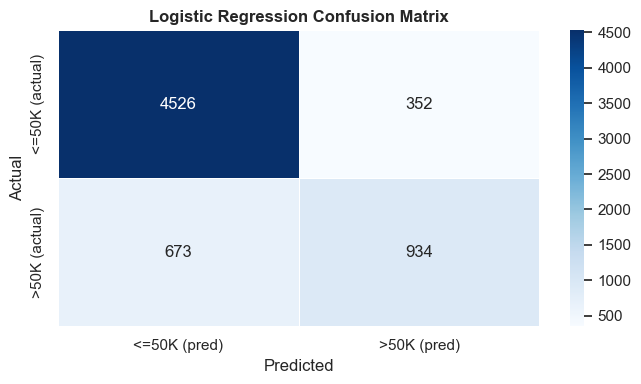

In [48]:
#Confusion matrix for Logistic Regression

def plot_confusion_matrix(preds_df, title, ax):
    """Quick confusion matrix plot using Pandas."""
    cm = preds_df.groupBy('income_binary', 'prediction').count().toPandas()
    cm_pivot = cm.pivot(index='income_binary', columns='prediction',values='count').fillna(0)
    cm_pivot.index =['<=50K (actual)', '>50K (actual)']
    cm_pivot.columns=['<=50K (pred)', '>50K (pred)']

    sns.heatmap(cm_pivot, annot=True, fmt='.0f',cmap='Blues',ax=ax,linewidths=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_confusion_matrix(lr_preds,'Logistic Regression Confusion Matrix',axes[0])

axes[1].set_visible(False)
plt.tight_layout()
plt.show()


In [49]:

#Ensemble of decision trees  usually beats logistic regression on tabular data

rf =RandomForestClassifier(featuresCol='features',labelCol='income_binary',
                             numTrees=100,maxDepth=8,seed=42)

rf_pipeline = Pipeline(stages=indexers + encoders + [final_assembler, rf])

print("Training Random Forest")
rf_model = rf_pipeline.fit(train_df)
rf_preds = rf_model.transform(test_df)

rf_auc = evaluator_auc.evaluate(rf_preds)
rf_acc = evaluator_acc.evaluate(rf_preds)

print(f"Random Forest Results:")
print(f"AUC:{rf_auc:.4f}")
print(f"Accuracy: {rf_acc:.4f}")


Training Random Forest
Random Forest Results:
AUC:0.9027
Accuracy: 0.8450


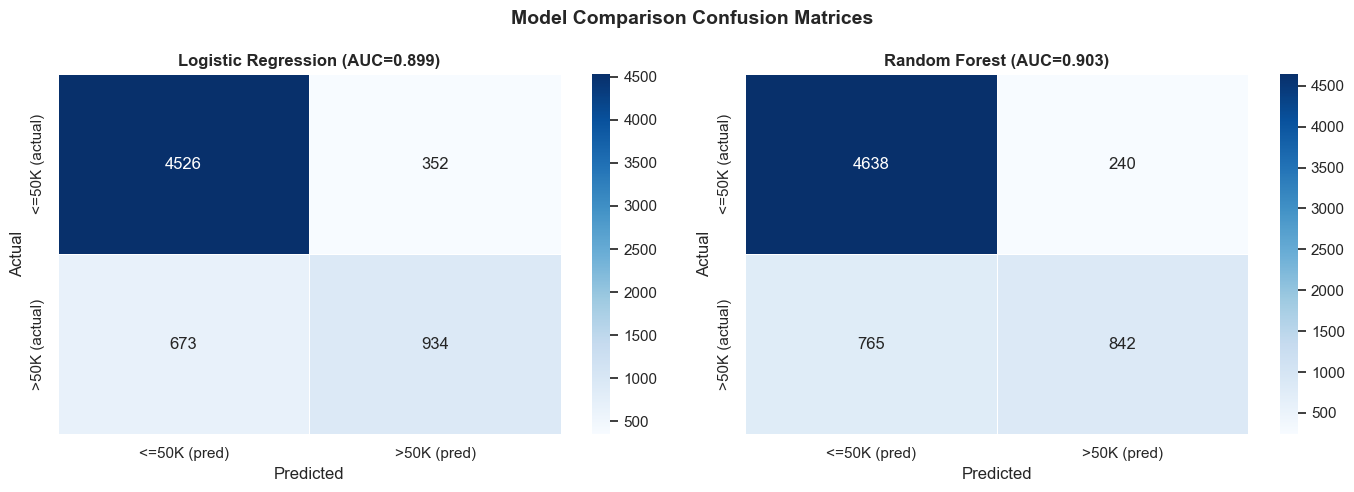

In [50]:
#Sideby side confusion matrices for both models

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_confusion_matrix(lr_preds,f'Logistic Regression (AUC={lr_auc:.3f})', axes[0])
plot_confusion_matrix(rf_preds,f'Random Forest (AUC={rf_auc:.3f})',axes[1])
plt.suptitle('Model Comparison Confusion Matrices',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png',dpi=150,bbox_inches='tight')
plt.show()


In [51]:
print("=" * 45)
print(f"{'Model':<25} {'AUC':>8} {'Accuracy':>10}")
print("-" * 45)
print(f"{'Logistic Regression':<25} {lr_auc:>8.4f} {lr_acc:>10.4f}")
print(f"{'Random Forest':<25} {rf_auc:>8.4f} {rf_acc:>10.4f}")
print("="* 45)

winner ="Random Forest" if rf_auc > lr_auc else "Logistic Regression"
print(f"Better model by AUC:{winner}")


Model                          AUC   Accuracy
---------------------------------------------
Logistic Regression         0.8992     0.8419
Random Forest               0.9027     0.8450
Better model by AUC:Random Forest


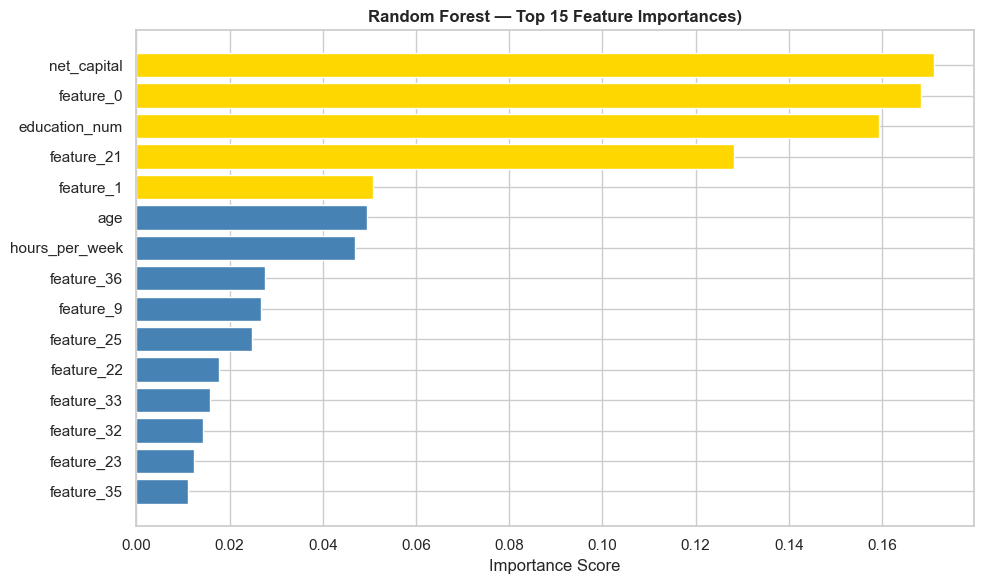

Top 5 most important features:
  1. net_capital                    → 0.1712
  2. feature_0                      → 0.1683
  3. education_num                  → 0.1593
  4. feature_21                     → 0.1282
  5. feature_1                      → 0.0507


In [52]:

# Which features actually matter for predicting income?

#Extract the actual RF model from the pipeline
rf_stage =rf_model.stages[-1]

assembler_stage =rf_model.stages[-2]
feature_names =assembler_stage.getInputCols()


# Build importances dataframe
importances = rf_stage.featureImportances.toArray()

if len(importances) > len(feature_names):
    feature_names = feature_names + [f'feature_{i}' for i in range(len(importances) - len(feature_names))]

feat_df = pd.DataFrame({'feature': feature_names[:len(importances)],
                         'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['gold' if i < 5 else 'steelblue' for i in range(len(feat_df))]
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest — Top 15 Feature Importances)', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
for i, (_, row) in enumerate(feat_df.head(5).iterrows(), 1):
    print(f"  {i}. {row['feature']:30s} → {row['importance']:.4f}")


## Answers to project questions

### 1) Why is it dangerous to blindly drop all rows containing "?"in this specificd ataset? How did consulting the metadata guide your imputation strategy?


In this dataset, the ? values appear mostly in columns like workclass and occupation, which are closely linked to income. If those rows are simply removed, it could eliminate a specific group of people rather than random entries. This can create selection bias and affect the results.

According to the dataset description, these columns represent employment categories. So instead of dropping those records, filling the missing values with the most common category is a safer approach. It helps keep the data intact while still allowing the feature to be used in the analysis.

### 2)Looking at your Unsupervised Learning results (PCA or K-Means), what hidden patterns did you discover that weren't immediately obvious from the raw data?

The clustering step creates groups that are clearly different based on age, hours worked, education and net capital.

One group generally has higher education levels and higher net capital. This group also shows a higher proportion of people with high income.

Another group is usually younger, with lower education levels and fewer working hours and it has a smaller share of high-income individuals.

Among all the features, net capital stands out as the strongest factor separating the groups.

### 3)Comparing your Logistic Regression and Random Forest models, which metric(Precision, Recall or AUC) do you consider most important for this specific business case, and why?

AUC is a reliable metric for comparing models because it measures how well a model can rank positive cases higher than negative ones across all possible thresholds. Unlike accuracy, it is less affected by class imbalance, which makes it more stable when the dataset is uneven.

Precision and recall become more important when there is a specific business cost tied to decisions, such as the impact of false positives or false negatives. However, as a first step to compare overall model performance, **AUC** is the most suitable choice in this case.

### 4)Based on your Random Forest feature importance, what actionable advice would you give to someone looking to maximize their chances of earning over$50K?

The main factors that influence income usually include education level, number of hours worked, type of occupation, age and capital gains or overall net capital.

Based on these patterns, practical steps would include improving education and skills, aiming for better-paying job roles, building long-term assets that generate capital gains and maintaining stable full-time employment when possible.

In [53]:
spark.stop()
print("Spark session closed. Analysis is  completed")


Spark session closed. Analysis is  completed
